# EDA and Feature Selection

This notebook follows a simple order:
1. Load and inspect data
2. Visualize data
3. Decide useful features for modeling

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ai_assistant_usage_student_life.csv")


print(df.shape)
df.head()

(10000, 11)


,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [2]:
df.info()

df.isna().sum()

print("\nDuplicated : ", df.duplicated().sum())



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  str    
 1   StudentLevel        10000 non-null  str    
 2   Discipline          10000 non-null  str    
 3   SessionDate         10000 non-null  str    
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  str    
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  str    
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), str(6)
memory usage: 791.1 KB

Duplicated :  0


Used again value count: 
 UsedAgain
True     7064
False    2936
Name: count, dtype: int64


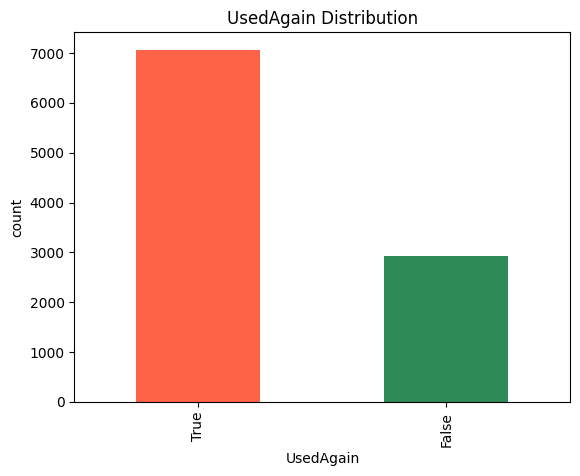

In [3]:
used_again_counts = df["UsedAgain"].value_counts()
print("Used again value count: \n", used_again_counts)
used_again_counts.plot(kind="bar", color=["tomato", "seagreen"], title="UsedAgain Distribution")
plt.ylabel("count")
plt.show()


 StudentLevel
StudentLevel
Undergraduate    5978
High School      2027
Graduate         1995
Name: count, dtype: int64


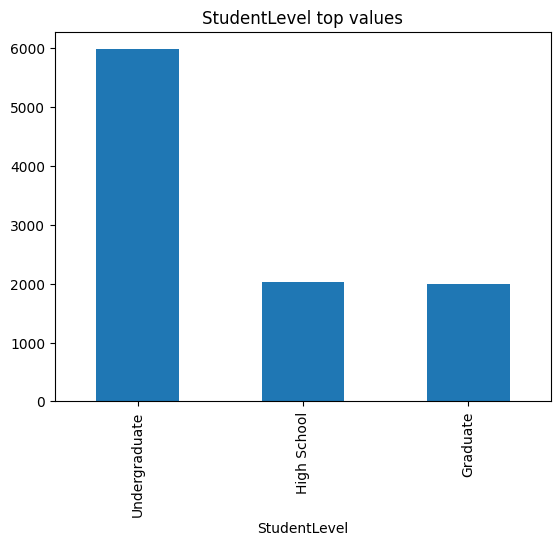


 Discipline
Discipline
Biology             1458
Computer Science    1445
Engineering         1430
Math                1422
Psychology          1418
History             1417
Business            1410
Name: count, dtype: int64


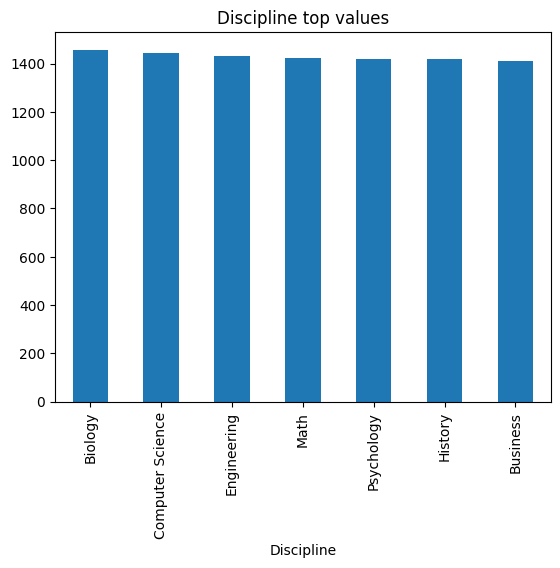


 TaskType
TaskType
Writing          3101
Studying         2040
Homework Help    1959
Coding           1948
Brainstorming     476
Research          476
Name: count, dtype: int64


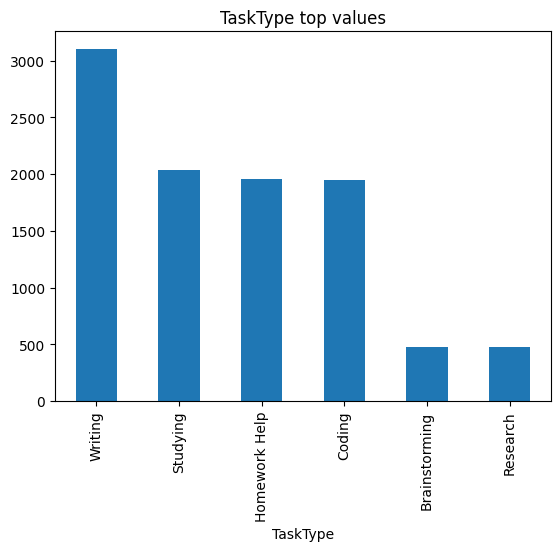


 FinalOutcome
FinalOutcome
Assignment Completed    4768
Idea Drafted            2866
Confused                1613
Gave Up                  753
Name: count, dtype: int64


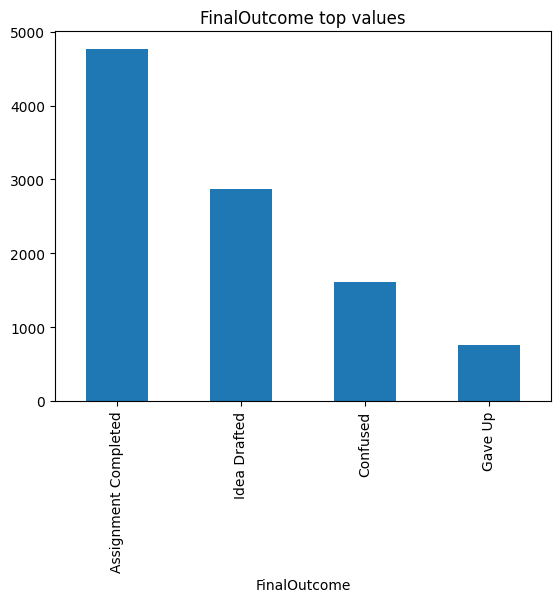

In [4]:
cat_cols = ["StudentLevel", "Discipline", "TaskType", "FinalOutcome"]
for c in cat_cols:
    print("\n", c)
    print(df[c].value_counts().head(10))
    df[c].value_counts().head(10).plot(kind="bar", title=f"{c} top values")
    plt.show()


SessionID                        str
StudentLevel                     str
Discipline                       str
SessionDate           datetime64[us]
SessionLengthMin             float64
TotalPrompts                   int64
TaskType                         str
AI_AssistanceLevel             int64
FinalOutcome                     str
UsedAgain                       bool
SatisfactionRating           float64
SessionMonth                   int32
SessionWeekday                   str
prompts_per_min              float64
duration_bin                category
dtype: object

UsedAgain rate by StudentLevel:
UsedAgain         False     True 
StudentLevel                     
Graduate       0.296742  0.703258
High School    0.286630  0.713370
Undergraduate  0.294915  0.705085


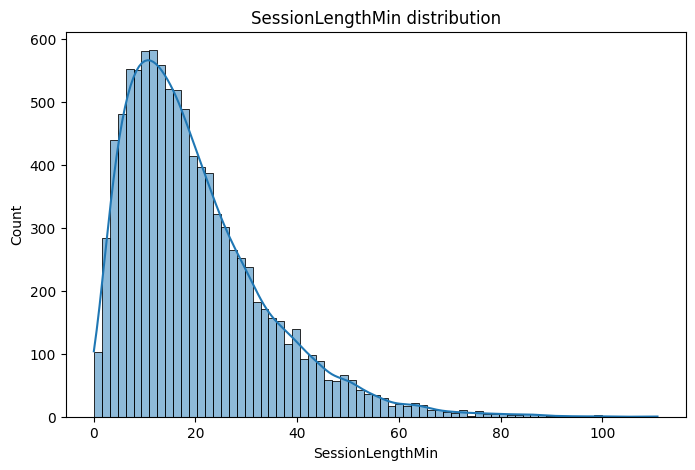

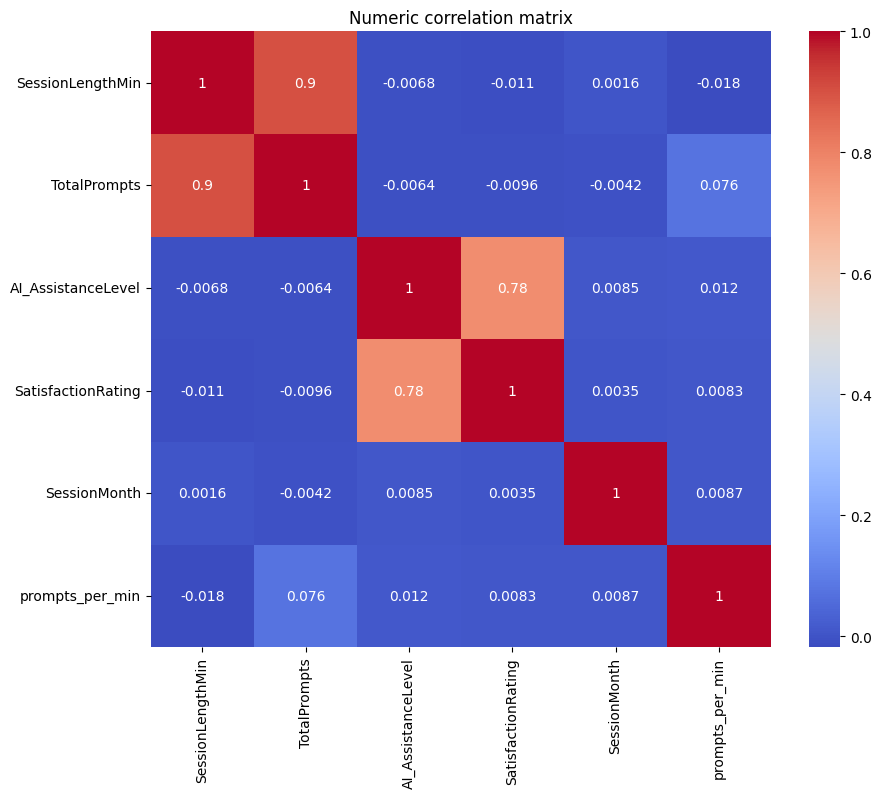

In [5]:
# Parse dates and basic feature creation
df['SessionDate'] = pd.to_datetime(df['SessionDate'])
df['SessionMonth'] = df['SessionDate'].dt.month
df['SessionWeekday'] = df['SessionDate'].dt.day_name()
# prompts per minute (avoid div-by-zero)
df['prompts_per_min'] = df['TotalPrompts'] / df['SessionLengthMin'].replace(0, 1)
# simple duration bins
df['duration_bin'] = pd.cut(df['SessionLengthMin'], bins=[0,5,15,30,60,999], labels=['0-5','6-15','16-30','31-60','60+'])
# dtypes and quick numeric summary
print(df.dtypes)
df[['SessionLengthMin','TotalPrompts','prompts_per_min']].describe()
# Target rate by StudentLevel
print('\nUsedAgain rate by StudentLevel:')
print(df.groupby('StudentLevel')['UsedAgain'].value_counts(normalize=True).unstack())
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['SessionLengthMin'], kde=True)
plt.title('SessionLengthMin distribution')
plt.show()
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Numeric correlation matrix')
plt.show()

In [6]:
# Consolidate rare categories and ordinal-encode StudentLevel
top_disc = df['Discipline'].value_counts().nlargest(10).index
df['Discipline_mod'] = df['Discipline'].where(df['Discipline'].isin(top_disc), 'Other')
top_task = df['TaskType'].value_counts().nlargest(8).index
df['TaskType_mod'] = df['TaskType'].where(df['TaskType'].isin(top_task), 'Other')
level_map = {'High School':0, 'Undergraduate':1, 'Graduate':2}
df['StudentLevel_ord'] = df['StudentLevel'].map(level_map)
df[['Discipline_mod','TaskType_mod','StudentLevel_ord']].head()

,Discipline_mod,TaskType_mod,StudentLevel_ord
0,Computer Science,Studying,1
1,Psychology,Studying,1
2,Business,Coding,1
3,Computer Science,Coding,1
4,Psychology,Writing,1
